In [1]:
from mapie.classification import MapieClassifier

In [2]:
import sys 
sys.path.append('/home/royhirsch/conformal/')

from data import get_dataloaders, read_and_split
from config import get_config_by_name
from conformal import get_conformal_module
from data import get_dataloaders

config = get_config_by_name('tissuemnist')
data = read_and_split(config)

# dls, t = get_dataloaders(config, conformal_module)
# train_dl = dls['train']
# valid_dl = dls['valid']
# test_dl = dls['test']


In [3]:
import numpy as np

class MapieWrapper():
    def __init__(self) -> None:
        self.classes_ = None
        self.trained_ = False
        
    def fit(self, x, y) -> None:
        self.classes_ = np.arange(len(np.unique(y)))
        self.trained_ = True

    def predict_proba(self, x) -> np.ndarray:
        return x

    def predict(self, x) -> np.ndarray:
        return x.argmax(1)

    def __sklearn_is_fitted__(self):
        return True


In [4]:
import scipy

probs = scipy.special.softmax(data['train']['preds'], 1)
est = MapieWrapper()
est.fit(probs, data['train']['labels'])

# mapie = MapieClassifier(estimator=est, method='aps', cv='prefit', random_state=42) 
# mapie.fit(probs, data['train']['labels'])
# y_preds, y_pss = mapie.predict(probs, alpha=0.9, include_last_label=True)


In [8]:
from mapie.metrics import classification_coverage_score
from sklearn.metrics import accuracy_score
import pandas as pd 

def count_null_set(y: np.ndarray) -> int:
    count = 0
    for pred in y[:, :]:
        if np.sum(pred) == 0:
            count += 1
    return count

method_params = {
    "naive": ("naive", False),
    "score": ("score", False),
    "aps": ("aps", True),
    "random_aps": ("aps", "randomized"),
    "raps": ("raps", True),
    "random_raps": ("raps", "randomized"),
    "top_k": ("top_k", False)
}

# method_params = {
#     "aps": ("aps", True),
# }


y_preds, y_pss = {}, {}
alphas = [0.1]

for name, (method, include_last_label) in method_params.items():
    mapie = MapieClassifier(estimator=est, method=method, cv="prefit", random_state=42) 
    mapie.fit(probs, data['train']['labels'])
    y_preds[name], y_pss[name] = mapie.predict(
        scipy.special.softmax(data['test']['preds'], 1), alpha=alphas, include_last_label=include_last_label)

nulls, coverages, accuracies, sizes = {}, {}, {}, {}
for name, (method, include_last_label) in method_params.items():
    accuracies[name] = accuracy_score(data['test']['labels'], y_preds[name])
    nulls[name] = [
        count_null_set(y_pss[name][:, :, i])  for i, _ in enumerate(alphas)
    ]
    coverages[name] = [
        classification_coverage_score(
            data['test']['labels'], y_pss[name][:, :, i]
        ) for i, _ in enumerate(alphas)
    ]
    sizes[name] = [
        y_pss[name][:, :, i].sum(axis=1).mean() for i, _ in enumerate(alphas)
    ]
coverage_90 = {method: coverage[0] for method, coverage in coverages.items()}
null_90 = {method: null[0] for method, null in nulls.items()}
width_90 = {method: width[0] for method, width in sizes.items()}
y_ps_90 = {method: y_ps[:, :, 0] for method, y_ps in y_pss.items()}

summary_df = pd.concat(
    [
        pd.Series(coverage_90),
        pd.Series(null_90),
        pd.Series(width_90)
    ],
    axis=1,
    keys=["Coverages", "Number of null sets", "Average prediction set sizes"]
).round(3)

summary_df


,Coverages,Number of null sets,Average prediction set sizes
naive,0.800,0,1.585
score,0.900,0,1.999
aps,0.943,0,2.538
random_aps,0.893,48,2.226
raps,0.942,0,2.632
random_raps,0.896,23,2.171
top_k,0.930,0,3.000


In [6]:

def count_null_set(y: np.ndarray) -> int:
    count = 0
    for pred in y[:, :]:
        if np.sum(pred) == 0:
            count += 1
    return count

chosen_alpha_indx = 9
print(alphas[chosen_alpha_indx])

nulls, coverages, accuracies, sizes = {}, {}, {}, {}
for name, (method, include_last_label) in method_params.items():
    accuracies[name] = accuracy_score(data['test']['labels'], y_preds[name])
    nulls[name] = [
        count_null_set(y_pss[name][:, :, i])  for i, _ in enumerate(alphas)
    ]
    coverages[name] = [
        classification_coverage_score(
            data['test']['labels'], y_pss[name][:, :, i]
        ) for i, _ in enumerate(alphas)
    ]
    sizes[name] = [
        y_pss[name][:, :, i].sum(axis=1).mean() for i, _ in enumerate(alphas)
    ]
coverage_90 = {method: coverage[chosen_alpha_indx] for method, coverage in coverages.items()}
null_90 = {method: null[chosen_alpha_indx] for method, null in nulls.items()}
width_90 = {method: width[chosen_alpha_indx] for method, width in sizes.items()}
y_ps_90 = {method: y_ps[:, :, chosen_alpha_indx] for method, y_ps in y_pss.items()}

summary_df = pd.concat(
    [
        pd.Series(coverage_90),
        pd.Series(null_90),
        pd.Series(width_90)
    ],
    axis=1,
    keys=["Coverages", "Number of null sets", "Average prediction set sizes"]
).round(3)


IndexError: list index out of range

In [ ]:
summary_df

NameError: name 'summary_df' is not defined

In [ ]:
summary_df

,Coverages,Number of null sets,Average prediction set sizes
naive,0.792,0,1.544
score,0.898,0,1.958
aps,0.946,0,2.462
random_aps,0.906,1,2.164
top_k,0.940,0,3.000


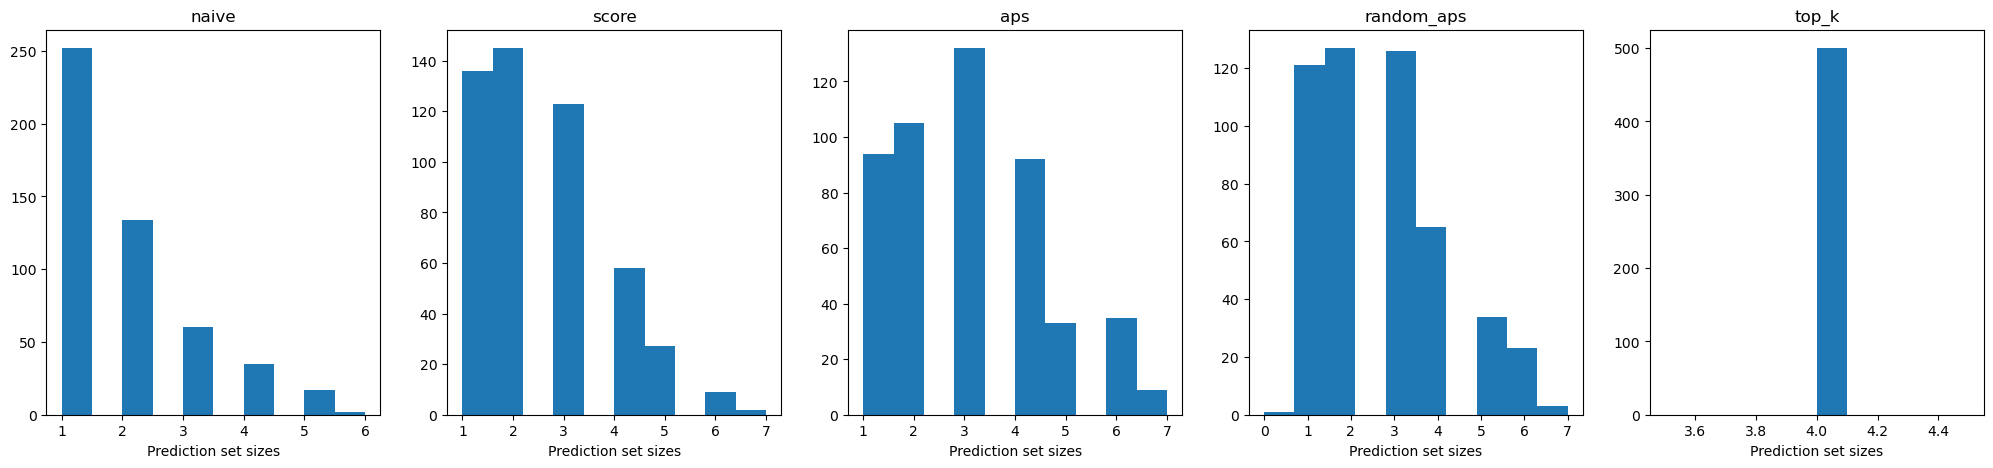

In [ ]:
import matplotlib.pyplot as plt

s=5
fig, axs = plt.subplots(1, len(y_preds), figsize=(s*len(y_preds), s))
for i, (method, y_ps) in enumerate(y_ps_90.items()):
    sizes = y_ps.sum(axis=1)
    axs[i].hist(sizes)
    axs[i].set_xlabel("Prediction set sizes")
    axs[i].set_title(method)
